<a href="https://colab.research.google.com/github/maheshraj19sep-hub/data-analytics-portfolio/blob/main/Customer_Spending_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("/content/sample_data/marketing_campaign.csv",sep=None, engine='python')
print(df.columns)


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df['total_spent']=df[['MntWines','MntFruits','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
print(df.total_spent)

0       1071
1         21
2        649
3         33
4        304
        ... 
2235    1159
2236     414
2237    1024
2238     629
2239     111
Name: total_spent, Length: 2240, dtype: int64


In [ ]:
df['age']=2026 - df['Year_Birth']
df['children'] = df['Kidhome'] + df['Teenhome']
print(df.children)

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: children, Length: 2240, dtype: int64


In [ ]:
df['total_purchases']=df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']].sum(axis=1)
print(df.total_spent)

0       1071
1         21
2        649
3         33
4        304
        ... 
2235    1159
2236     414
2237    1024
2238     629
2239     111
Name: total_spent, Length: 2240, dtype: int64


In [ ]:
df['customer_segment']=pd.qcut(df['total_spent'],q=4,labels=['low','medium','high','premium'])
df[['customer_segment','total_spent']]


,customer_segment,total_spent
0,premium,1071
1,low,21
2,high,649
3,low,33
4,high,304
...,...,...
2235,premium,1159
2236,high,414
2237,premium,1024
2238,high,629


In [ ]:
df.groupby('customer_segment')[['total_spent','total_purchases']].mean()

/tmp/ipykernel_164/4216057608.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_segment')[['total_spent','total_purchases']].mean()


,total_spent,total_purchases
customer_segment,,
low,29.142857,6.176367
medium,139.822785,10.989150
high,523.069643,20.228571
premium,1064.741071,22.114286


In [ ]:
df.groupby('Recency')['total_spent'].mean()

,total_spent
Recency,
0,324.857143
1,480.708333
2,432.750000
3,454.965517
4,478.222222
...,...
95,522.842105
96,428.800000
97,462.400000


In [ ]:
df.groupby(pd.qcut(df['Income'],4))['total_spent'].mean()

/tmp/ipykernel_164/3712541058.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Income'],4))['total_spent'].mean()


,total_spent
Income,
"(1729.999, 35303.0]",58.925993
"(35303.0, 51381.5]",183.077617
"(51381.5, 68522.0]",596.651625
"(68522.0, 666666.0]",921.662455


In [ ]:
df[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases']].sum()

,0
NumWebPurchases,9150
NumStorePurchases,12970
NumCatalogPurchases,5963


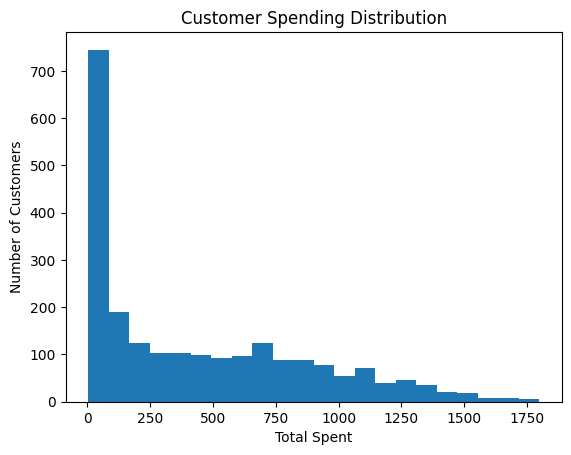

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['total_spent'],bins=22)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")
plt.show()

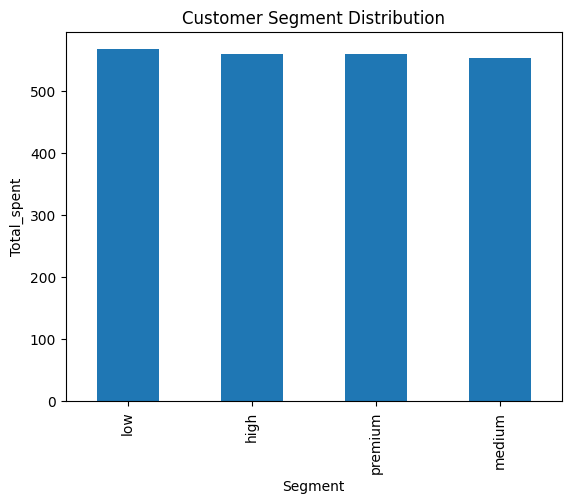

In [ ]:
df['customer_segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Total_spent")
plt.show()

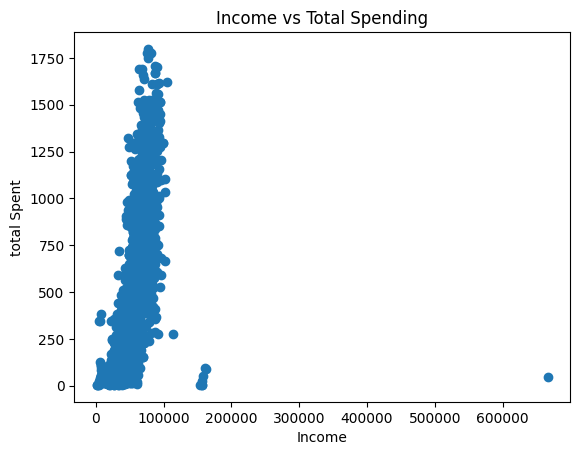

In [ ]:
plt.scatter(df['Income'],df['total_spent'])
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("total Spent")
plt.show()

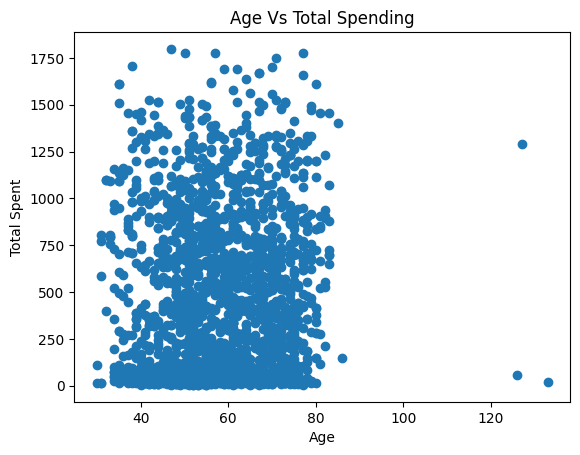

In [ ]:
plt.scatter(df['age'],df['total_spent'])
plt.title("Age Vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spent")
plt.show()

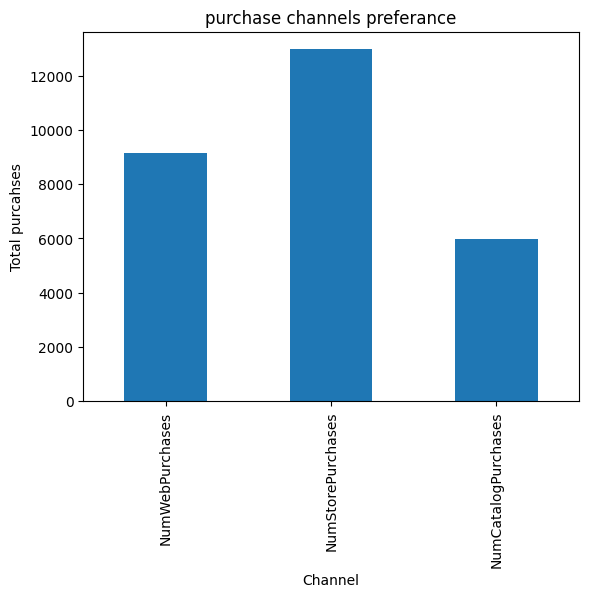

In [ ]:
channels=df[['NumWebPurchases','NumStorePurchases','NumCatalogPurchases']].sum()
channels.plot(kind='bar')
plt.title("purchase channels preferance")
plt.xlabel("Channel")
plt.ylabel("Total Purcahases")
plt.ylabel("Total purcahses")
plt.show()

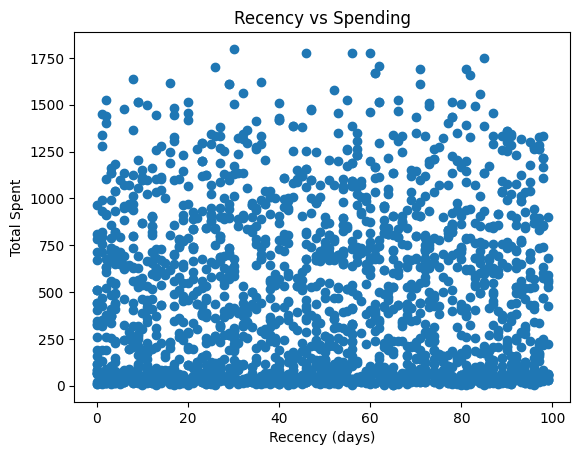

In [ ]:
plt.scatter(df['Recency'], df['total_spent'])
plt.title("Recency vs Spending")
plt.xlabel("Recency (days)")
plt.ylabel("Total Spent")
plt.show()